# Business Case 3 — Revenue Protection

## Business Objective

Identify the operational impact of medical appointment no-shows and use predictive analytics to support actions that can reduce missed appointment capacity.

The objective is to help management:

* Quantify appointment no-shows
* Identify groups with higher no-show rates
* Estimate the volume of appointments potentially at risk
* Support targeted reminder and rescheduling strategies
* Protect available appointment capacity

> The dataset does not contain actual revenue or appointment-value information. Therefore, this analysis measures missed appointment volume rather than claiming a specific monetary loss.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df_business = pd.read_csv("../../data/Medical_appointment_data.csv")

print("Dataset shape:", df_business.shape)

Dataset shape: (109593, 26)


In [2]:
# Create a working copy
df = df_business.copy()

# Standardize the no-show target
df['no_show'] = df['no_show'].astype(str).str.strip().str.lower()

# Convert no-show status to numeric
df['no_show_numeric'] = df['no_show'].map({
    'no': 0,
    'yes': 1
})

print("No-show counts:")
print(df['no_show'].value_counts())

print("\nNo-show percentages:")
print(
    (df['no_show'].value_counts(normalize=True) * 100)
    .round(2)
)

No-show counts:
no_show
no     74761
yes    34832
Name: count, dtype: int64

No-show percentages:
no_show
no     68.22
yes    31.78
Name: proportion, dtype: float64


In [3]:
# Remove exact duplicate records

before = len(df)

df = df.drop_duplicates().copy()

after = len(df)

print("Rows before removing duplicates:", before)
print("Duplicate rows removed:", before - after)
print("Rows after removing duplicates:", after)

Rows before removing duplicates: 109593
Duplicate rows removed: 36
Rows after removing duplicates: 109557


In [4]:
# Calculate overall appointment and no-show metrics

total_appointments = len(df)
total_no_shows = df['no_show_numeric'].sum()
total_attended = total_appointments - total_no_shows

no_show_rate = (total_no_shows / total_appointments) * 100
attendance_rate = (total_attended / total_appointments) * 100

print("Revenue Protection Metrics")
print("--------------------------")
print("Total appointments :", total_appointments)
print("Attended           :", total_attended)
print("No-shows           :", total_no_shows)
print("Attendance rate    :", round(attendance_rate, 2), "%")
print("No-show rate       :", round(no_show_rate, 2), "%")

Revenue Protection Metrics
--------------------------
Total appointments : 109557
Attended           : 74726
No-shows           : 34831
Attendance rate    : 68.21 %
No-show rate       : 31.79 %


     status  appointments
0  Attended         74726
1   No-show         34831


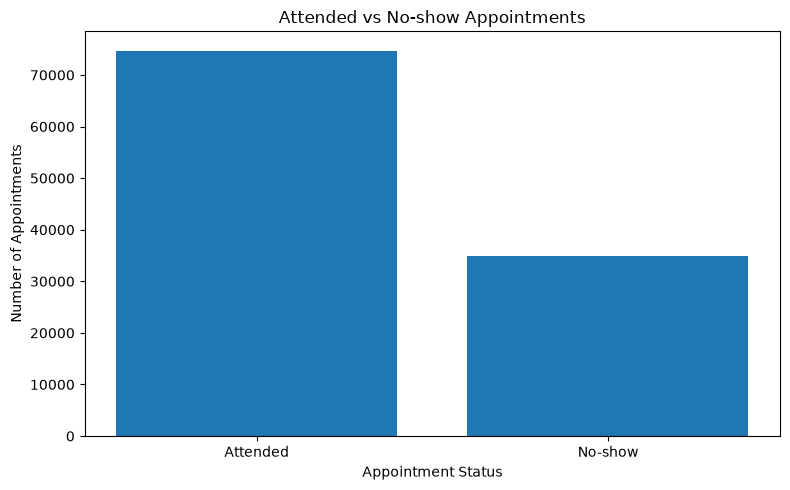

In [5]:
# Prepare attendance summary

attendance_summary = pd.DataFrame({
    'status': ['Attended', 'No-show'],
    'appointments': [total_attended, total_no_shows]
})

print(attendance_summary)

# Visualize attended vs no-show appointments

plt.figure(figsize=(8, 5))

plt.bar(
    attendance_summary['status'],
    attendance_summary['appointments']
)

plt.xlabel('Appointment Status')
plt.ylabel('Number of Appointments')
plt.title('Attended vs No-show Appointments')

plt.tight_layout()
plt.show()

In [6]:
# Calculate no-show volume and rate by specialty

specialty_no_show = (
    df.groupby('specialty')
      .agg(
          total_appointments=('no_show_numeric', 'count'),
          no_shows=('no_show_numeric', 'sum')
      )
      .reset_index()
)

specialty_no_show['no_show_rate_pct'] = (
    specialty_no_show['no_shows']
    / specialty_no_show['total_appointments']
    * 100
)

specialty_no_show = specialty_no_show.sort_values(
    'no_shows',
    ascending=False
)

print("No-show volume and rate by specialty:")
print(
    specialty_no_show.round(2).to_string(index=False)
)

No-show volume and rate by specialty:
           specialty  total_appointments  no_shows  no_show_rate_pct
       psychotherapy               28642      9263             32.34
       physiotherapy               21001      7218             34.37
      speech therapy               22321      6234             27.93
occupational therapy               11318      2701             23.86
            pedagogo                3535       565             15.98
                 enf                1681       332             19.75
              assist                 635       171             26.93
   sem especialidade                 324       171             52.78


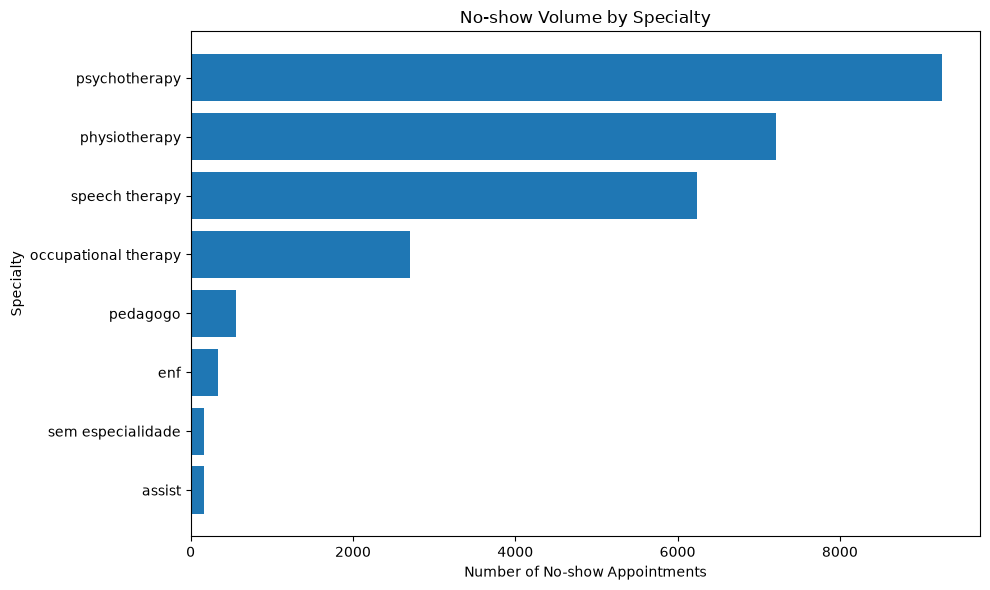

In [7]:
# Visualize no-show volume by specialty

specialty_plot = specialty_no_show.sort_values(
    'no_shows',
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    specialty_plot['specialty'],
    specialty_plot['no_shows']
)

plt.xlabel('Number of No-show Appointments')
plt.ylabel('Specialty')
plt.title('No-show Volume by Specialty')

plt.tight_layout()
plt.show()

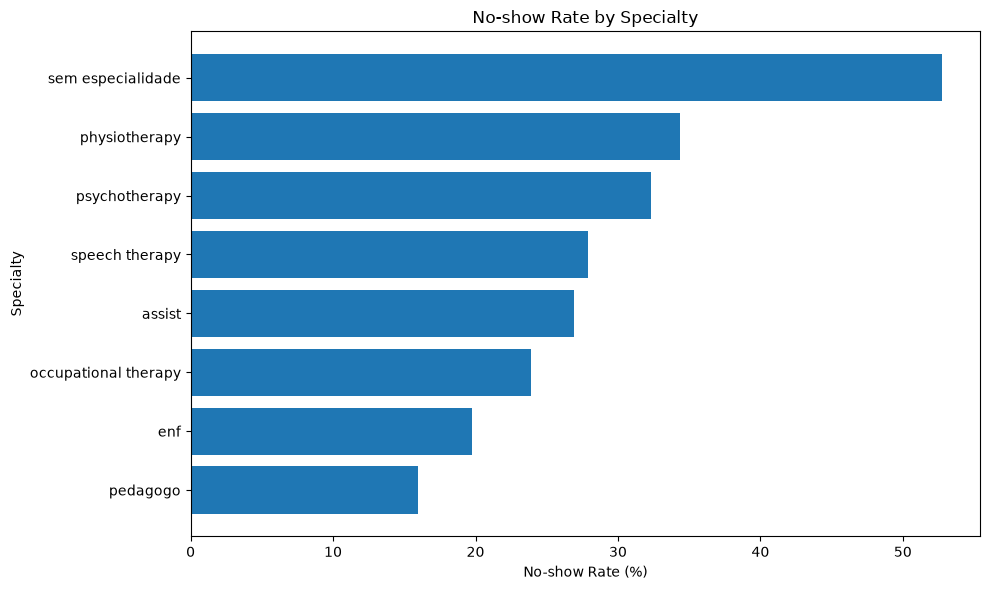

In [8]:
# Visualize no-show rate by specialty

specialty_rate_plot = specialty_no_show.sort_values(
    'no_show_rate_pct',
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    specialty_rate_plot['specialty'],
    specialty_rate_plot['no_show_rate_pct']
)

plt.xlabel('No-show Rate (%)')
plt.ylabel('Specialty')
plt.title('No-show Rate by Specialty')

plt.tight_layout()
plt.show()

In [9]:
# Classify specialties based on no-show volume

specialty_impact = specialty_no_show.copy()

specialty_impact['impact_level'] = pd.cut(
    specialty_impact['no_shows'],
    bins=[-1, 1000, 5000, float('inf')],
    labels=['Low', 'Medium', 'High']
)

specialty_impact = specialty_impact.sort_values(
    'no_shows',
    ascending=False
)

print("Specialty revenue-protection impact:")
print(
    specialty_impact[
        [
            'specialty',
            'total_appointments',
            'no_shows',
            'no_show_rate_pct',
            'impact_level'
        ]
    ].round(2).to_string(index=False)
)

Specialty revenue-protection impact:
           specialty  total_appointments  no_shows  no_show_rate_pct impact_level
       psychotherapy               28642      9263             32.34         High
       physiotherapy               21001      7218             34.37         High
      speech therapy               22321      6234             27.93         High
occupational therapy               11318      2701             23.86       Medium
            pedagogo                3535       565             15.98          Low
                 enf                1681       332             19.75          Low
              assist                 635       171             26.93          Low
   sem especialidade                 324       171             52.78          Low


In [10]:
# Calculate the share of all no-shows from the top 3 specialties

top_3 = specialty_impact.head(3)

top_3_no_shows = top_3['no_shows'].sum()

top_3_no_show_share = (
    top_3_no_shows / total_no_shows * 100
)

print("Top 3 specialties by no-show volume:")
print(top_3[['specialty', 'no_shows']].to_string(index=False))

print("\nTop 3 no-shows:", top_3_no_shows)
print(
    "Share of all no-shows:",
    round(top_3_no_show_share, 2),
    "%"
)

Top 3 specialties by no-show volume:
     specialty  no_shows
 psychotherapy      9263
 physiotherapy      7218
speech therapy      6234

Top 3 no-shows: 22715
Share of all no-shows: 65.21 %


In [11]:
# Estimate potentially recoverable appointments under different scenarios

recovery_rates = [0.10, 0.20, 0.30]

recovery_scenarios = pd.DataFrame({
    'Recovery Scenario': ['10%', '20%', '30%'],
    'Potentially Recovered Appointments': [
        round(total_no_shows * rate)
        for rate in recovery_rates
    ]
})

print("Potential appointment recovery scenarios:")
print(recovery_scenarios.to_string(index=False))

Potential appointment recovery scenarios:
Recovery Scenario  Potentially Recovered Appointments
              10%                                3483
              20%                                6966
              30%                               10449


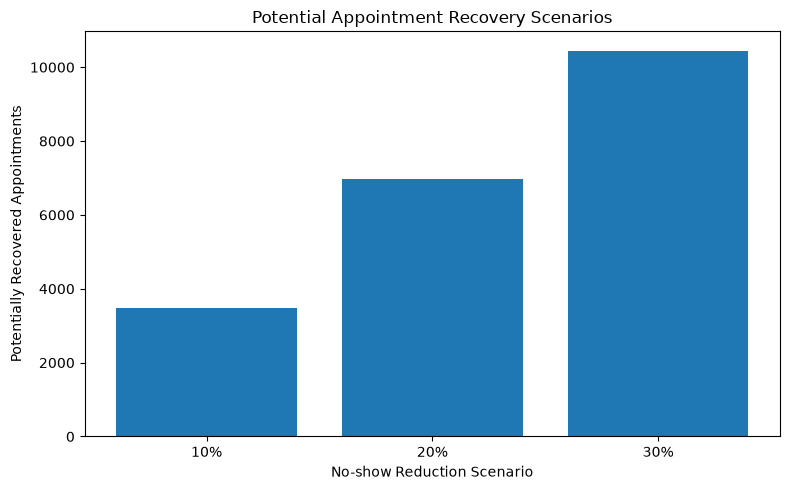

In [12]:
plt.figure(figsize=(8, 5))

plt.bar(
    recovery_scenarios['Recovery Scenario'],
    recovery_scenarios['Potentially Recovered Appointments']
)

plt.xlabel('No-show Reduction Scenario')
plt.ylabel('Potentially Recovered Appointments')
plt.title('Potential Appointment Recovery Scenarios')

plt.tight_layout()
plt.show()

In [13]:
# Create a specialty-level intervention summary

specialty_intervention = specialty_no_show.copy()

specialty_intervention['no_show_share_pct'] = (
    specialty_intervention['no_shows']
    / total_no_shows * 100
)

specialty_intervention = specialty_intervention.sort_values(
    'no_shows',
    ascending=False
)

print("Specialty-level intervention summary:")
print(
    specialty_intervention[
        [
            'specialty',
            'total_appointments',
            'no_shows',
            'no_show_rate_pct',
            'no_show_share_pct'
        ]
    ].round(2).to_string(index=False)
)

Specialty-level intervention summary:
           specialty  total_appointments  no_shows  no_show_rate_pct  no_show_share_pct
       psychotherapy               28642      9263             32.34              26.59
       physiotherapy               21001      7218             34.37              20.72
      speech therapy               22321      6234             27.93              17.90
occupational therapy               11318      2701             23.86               7.75
            pedagogo                3535       565             15.98               1.62
                 enf                1681       332             19.75               0.95
              assist                 635       171             26.93               0.49
   sem especialidade                 324       171             52.78               0.49


In [14]:
# Create final summary table for Revenue Protection

revenue_protection_summary = specialty_intervention[
    [
        'specialty',
        'total_appointments',
        'no_shows',
        'no_show_rate_pct',
        'no_show_share_pct'
    ]
].copy()

revenue_protection_summary.columns = [
    'Specialty',
    'Total Appointments',
    'No-shows',
    'No-show Rate (%)',
    'Share of All No-shows (%)'
]

print("Revenue Protection Summary:")
print(
    revenue_protection_summary.round(2).to_string(index=False)
)

Revenue Protection Summary:
           Specialty  Total Appointments  No-shows  No-show Rate (%)  Share of All No-shows (%)
       psychotherapy               28642      9263             32.34                      26.59
       physiotherapy               21001      7218             34.37                      20.72
      speech therapy               22321      6234             27.93                      17.90
occupational therapy               11318      2701             23.86                       7.75
            pedagogo                3535       565             15.98                       1.62
                 enf                1681       332             19.75                       0.95
              assist                 635       171             26.93                       0.49
   sem especialidade                 324       171             52.78                       0.49


## Business Insight — Revenue Protection

The analysis shows that no-shows represent a significant amount of missed appointment capacity.

### Key Findings

* **34,831 appointments** were recorded as no-shows, representing a **31.79% overall no-show rate**.
* **Psychotherapy** recorded the highest number of no-shows with **9,263**, accounting for **26.59% of all no-shows**.
* **Physiotherapy** recorded **7,218 no-shows**, with a no-show rate of **34.37%**.
* **Speech therapy** recorded **6,234 no-shows**, accounting for **17.90% of all no-shows**.
* Together, psychotherapy, physiotherapy, and speech therapy contributed **22,715 no-shows**, representing **65.21% of all missed appointments**.
* Scenario analysis shows that a **10%, 20%, or 30% reduction in no-shows** could potentially recover approximately **3,483, 6,966, or 10,449 appointment slots**, respectively.

### Operational Approach

The findings can support targeted appointment-management strategies:

* Prioritize additional engagement for specialties with high no-show volumes.
* Use predictive risk scores to identify individual appointments that may require additional reminders.
* Encourage confirmation or rescheduling for higher-risk appointments.
* Monitor no-show rates regularly to measure whether interventions improve attendance.

### Business Value

Reducing missed appointments can help healthcare organizations make better use of available appointment capacity and reduce the operational impact of unused slots.

The analysis does **not estimate monetary revenue loss**, because the dataset does not contain appointment prices, treatment costs, or revenue information. The recovery scenarios therefore represent **potentially recovered appointment capacity**, not guaranteed financial savings.

> Recovery scenarios are illustrative estimates. Actual results would depend on the effectiveness of patient-engagement interventions and operational implementation.
